#Vision Project : Facial Emotion Recognition


#0 : File Initialization
- Imports
- Reproducibility : `set_seeds(seed)` function
- Device agnostic code

##0.1. Imports

- **torch** : *Bibliothèque principale PyTorch pour la manipulation de tenseurs et la différentiation automatique.*

  - **torchvision :** Module pour vision par ordinateur
  - **torch.utils.data :** Outils pour la gestion des données
  - **torch.optim :** Module dédié aux algos d'optimisation

- **matplotlib :** Affichage graphique de données
- **pathlib :** Gestion orientée objet et portable des chemins de fichiers et dossiers.
---

In [ ]:
import torch

# Torchvision
import torchvision
from torchvision import datasets        # Accès à une base de données de datasets à charger
from torch.utils.data import Dataset    # Classe abstraite pour définir le jeu de données custom
from torch.utils.data import DataLoader # Outil de chargement du dataset (batch, parallélisation)
from torchvision import transforms
from torchvision.transforms import ToTensor

# Required for models
import torch.optim as optim
from torch import nn
from torch.optim.lr_scheduler import StepLR

# Visualisation des données :
import matplotlib.pyplot as plt

# Creation du custom dataset
from pathlib import Path

- **tqdm :**  Barre de progression visuelle pour les boucles, utile pour suivre l'avancement d'un entraînement ou d'un traitement.
- **torchmetrics :** fonctions standardisées de mesure (accuracy, F1, confusion matrix, etc.)
- **mlxtend :** Outils pour le ML, fonctions d’évaluation, visualisation et manipulation de données (on utilisera la visualisation)




In [ ]:
# Barre de chargement
from tqdm import tqdm

# Confusion Matrix
import torchmetrics
import mlxtend
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

print(f"mlxtend version: {mlxtend.__version__}")

# Vérification de la version minimale
major, minor, *_ = map(int, mlxtend.__version__.split("."))
assert major == 0 and minor >= 19, "mlxtend version should be >= 0.19.0"


##0.2. Manual Seed

Générateur de random seeds (numpy, python, pytorch et cuda)
- fonction utile pour générer rapidement les seeds avant entrainement.

> Si utilisé dans une cellule isolée, le générateur ne se mettra pas a jour a l'execution des suivantes.

---

In [ ]:
import numpy as np
import random

# Hyperparameter
MANUAL_SEED = 42

def set_seeds(seed):
  # Seeds
  random.seed(seed)                  # Python seed
  np.random.seed(seed)               # Numpy seed
  torch.manual_seed(seed)            # Pytoch seed (CPU)
  torch.cuda.manual_seed(seed)       # Pytorch Cuda seed (active GPU)
  torch.cuda.manual_seed_all(seed)   # Pytorch Cuda seed (all GPU)

set_seeds(42)


##0.3. device agnostic code :
- définir le device dans toute situation (cuda ou pas)

---



In [ ]:
# device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

# 1 : *Dataset* and *DataLoader*


##1.1. Téléchargement du **Dataset**
- **Dataset :** FER2013
- **Origin :** [Kaggle — FER2013](https://www.kaggle.com/datasets/msambare/fer2013)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("msambare/fer2013")

print("Path to dataset:", path)

Assignation a un path.

In [ ]:
data_path = Path(path)
train_path = data_path / "train"
test_path = data_path / "test"

## 1.2. Definition des augmentations et des sets Train et Test
**Train** :
* Random effet mirroir
* Random resize / crop
* Random rotation

**Test :** (Transformations minimales requises)
* Grayscale : merge les 3 canaux R G B présents initialement
* ToTensor : convertit les objets *image* en Tenseurs pytorc


In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop((48,48)),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# required transforms
transform_min = transforms.Compose([
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

Définition des sets train et test :
- `datasets.ImageFolder(root, transform)` : classe de torchvision.datasets qui permet de charger automatiquement un jeu de données d’images organisé en dossiers.
  - `root` : Root directory path.
  - `transform` :  A function/transform that takes in a PIL image or torch.Tensor

In [ ]:
train_data = datasets.ImageFolder(root=train_path, transform=transform_min)
test_data  = datasets.ImageFolder(root=test_path, transform=transform_min)

train_data_augmented = datasets.ImageFolder(root=train_path, transform=train_transform)
test_data_augmented  = datasets.ImageFolder(root=test_path, transform=transform_min)

Dataset information visualization :
- Class names
- Class idx

In [ ]:
class_names = train_data.classes
class_idx = train_data.class_to_idx
print(f"classes : {class_names}")
print(f"idx: {class_idx}")

classes : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
idx: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


Nettoyage du Dataset :

- Suppression des classes trop peu représentées (disgust)

In [ ]:
from torch.utils.data import Subset

def remove_class(dataset, class_idx):
    indices = [i for i, (_, label) in enumerate(dataset.samples) if label != class_idx]
    return Subset(dataset, indices)

# Removing disgust :
disgust_idx = train_data.class_to_idx['disgust']
# Minimal transforms set (seulement pour visualiser le dataset initial)
train_data_filtered = remove_class(train_data, disgust_idx)
test_data_filtered  = remove_class(test_data, disgust_idx)

# Augmented set
train_data_augmented_filtered = remove_class(train_data_augmented, disgust_idx)
test_data_augmented_filtered  = remove_class(test_data_augmented, disgust_idx)

In [ ]:
class_names_augmented_filtered = [c for c in class_names if c != disgust_idx]
print(class_names_augmented_filtered)

##**6 Classes :**
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Remapping des labels

In [ ]:
import torch

class RemapLabels(torch.utils.data.Dataset):
    def __init__(self, subset, remove_idx):
        self.subset = subset
        self.remove_idx = remove_idx

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if label > self.remove_idx:
            label -= 1
        return img, label

# On reféfinit les labels aux classes restantes
train_data_remap = RemapLabels(train_data_filtered, disgust_idx)
test_data_remap  = RemapLabels(test_data_filtered, disgust_idx)

train_data_augmented_remap = RemapLabels(train_data_augmented_filtered, disgust_idx)
test_data_augmented_remap  = RemapLabels(test_data_augmented_filtered, disgust_idx)

In [ ]:
class_names_augmented_filtered = [c for c in class_names if c != 'disgust']
print(class_names_augmented_filtered)

##1.3. Visualisation des données :



In [ ]:
X, y = train_data_remap[0]
X

Comparaison set initial / set augmenté

**IMPORTANT :** pour assurer la reproductibilité, imposer un `set_seeds` avant le début de l'entrainement.
> Cela permettra d'obtenir les mêmes augmentations pour chaque entrainement.

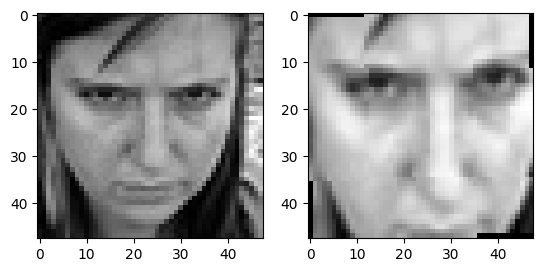

In [ ]:
X, y = train_data_remap[12]

# Image initiale
plt.subplot(1,2,1)
plt.imshow(X.squeeze(), cmap="gray")


# Image augmentée
X, y = train_data_augmented_remap[12]
plt.subplot(1,2,2)
plt.imshow(X.squeeze(), cmap="gray")


Visualisation d'un echantillon du dataset après augmentation

In [ ]:
fig = plt.figure(figsize=(8,4))
rows, cols = 3, 8
for i in range(1, rows*cols + 1):
  random_idx = torch.randint(0, len(train_data_augmented_remap), size=[1]).item()
  X, y = train_data_augmented_remap[random_idx]
  fig.add_subplot(rows, cols, i)
  plt.imshow(X.squeeze(), cmap="gray")
  plt.axis(False)
  plt.title(class_names_augmented_filtered[y])

##1.4. Definition des Dataloaders

In [ ]:
train_dataloader = DataLoader(train_data_augmented_remap,
                              batch_size=32,
                              num_workers=2,
                              shuffle=True)
test_dataloader = DataLoader(test_data_augmented_remap, # Augmented ou pas, même résultat
                             batch_size=32,
                             num_workers=2,
                             shuffle=False) # Shuffle non necessaire pour le set de test


print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Number of train Batches: {len(train_dataloader)}")

In [ ]:
train_data_batch, train_labels_batch = next(iter(train_dataloader))
train_data_batch.shape # 898 batches de 32 elements (= 28 000 images)

#2 : Model

Model I :
- Block 1
  - Conv2d
  - ReLu
  - Conv2d
  - ReLu
  - MaxPool2d
- Block 2
  - Conv2d
  - ReLu
  - Conv2d
  - ReLu
  - MaxPool2d
- Classifier :
  - Flatten
  - Linear

In [ ]:
class EmotionCNN(nn.Module):
    """
    Model Architecture : TinyVGG like
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )


        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*12*12, #*12*12 car pooling
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor): # On override forward
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

#3 : Training

##3.0. Variables to track progress

In [ ]:
train_acc_list = ([])
train_loss_list = ([])

test_acc_list = ([])
test_loss_list = ([])

##3.1. Training and Test functions :

###Training function
- `train_step` : one epoch training
    - `model` : type nn.Module
    - `data_loader` : type DataLoader
    - `loss_fn` : type nn.Module
    - `optimizer` : type Optimizer
    - `accuracy_fn` : function
    - `device` : type string

The training function contains five steps :
1.   Forward pass
2.   Loss
3.   Zero grad *(specific to Pytorch)*
4.   Backpropagation
5.   Optimizer step



In [ ]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):

    train_loss
    train_acc = 0, 0

    model.to(device)
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device) # On se met sur le device actuel (si CUDA, X sera envoyé sur le GPU)

        # Etape 1 : Forward Pass
        y_pred = model(X)

        # Etape 2 : on calcule la perte et l'accuracy
        loss = loss_fn(y_pred, y)
        train_loss += loss

        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred)

        # Etape 3 : on remet a zéro l'optimizer
        optimizer.zero_grad()

        # Etape 4 : backpropagation sur la graphe de calcul
        loss.backward()

        # Etape 5 : Application de l'optimizer (SGD)
        optimizer.step()

    # Perte et Accuracy
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)

    # On ajoute au CPU avant d'append pour éviter les erreurs liées au device
    train_loss_list.append(train_loss.cpu().item())
    train_acc_list.append(train_acc)


    print(f"Train loss: {train_loss} | Train accuracy: {train_acc}%")






##**Test function**

In [ ]:
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)

    #On passe en mode d'evaluation pour accélérer le temps de calcul au test
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)

            # Forward pass
            test_pred = model(X)

            # Calcul de la perte de accuracy
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y,
                                    y_pred=test_pred
            )

        #Normalisation des valeurs (-> on fait une moyenne d'accuracy et de perte sur le batch)
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        #Avant d'append, on déplace sur le GPU si device = CUDA
        test_loss_list.append(test_loss.cpu().item())
        test_acc_list.append(test_acc)

        print(f"Test loss: {test_loss} | Test accuracy: {test_acc}%\n")

##**Accuracy function**

In [ ]:
def accuracy_fn(y_pred, y_true):
    """Calcule l'accuracy sur un batch"""
    y_pred_classes = torch.argmax(y_pred, dim=1)
    correct = (y_pred_classes == y_true).sum().item()
    acc = correct / len(y_true)
    # Return accuracy as a percentage
    return 100 * acc

##3.2. Training loop

* Hyperparameters :

In [ ]:
# Reproducibility
MANUAL_SEED= 42

# Model
INPUT_SHAPE = 1
HIDDEN_UNITS = 128
NUM_CLASSES = 6

# Training
EPOCHS = 45
LEARNING_RATE = 0.05


In [ ]:
# Initializing model
set_seeds(MANUAL_SEED)
model = EmotionCNN(input_shape=INPUT_SHAPE,
                  hidden_units=HIDDEN_UNITS,
                  output_shape=NUM_CLASSES)
model

Definition de la loss function et de l'optimizer
* Ajout d'un scheduler pour adapter la learning rate

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(),
                             lr=LEARNING_RATE)
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

In [ ]:
torch.manual_seed(42)
print(device)

# Train et test du modèle
epochs = EPOCHS
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader,
        model=model,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )
    scheduler.step()

##3.3. Plotting the progress

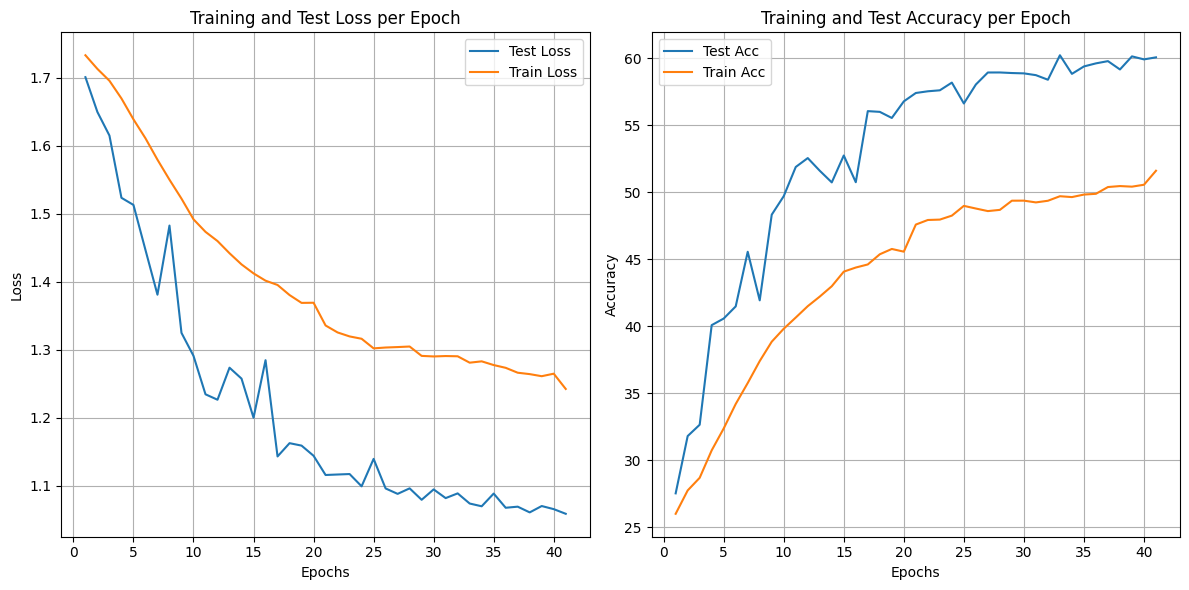

In [ ]:
# Préparation de la figure
train_epochs = range(1, len(train_acc_list) + 1)
test_epochs = range(1, len(test_acc_list) + 1)

plt.figure(figsize=(12, 6))

# Plot de la loss
plt.subplot(1, 2, 1)
plt.plot(test_epochs, test_loss_list, label="Test Loss" )
plt.plot(train_epochs, train_loss_list, label="Train Loss") # Assuming train_loss_list has the same length as train_acc_list
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Test Loss per Epoch")
plt.legend()
plt.grid(True)

# Plot de l'accuracy
plt.subplot(1, 2, 2)
plt.plot(test_epochs, test_acc_list, label="Test Acc" )
plt.plot(train_epochs, train_acc_list, label="Train Acc")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy per Epoch")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Confusion matrice :

In [ ]:
# 1 : predictions
y_preds = []
model.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    X = X.to(device)
    y = y.to(device)

    y_logit = model(X)
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
    y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)

In [ ]:
targets = []
for _, label in test_data_final:
    targets.append(label)
targets_tensor = torch.tensor(targets)


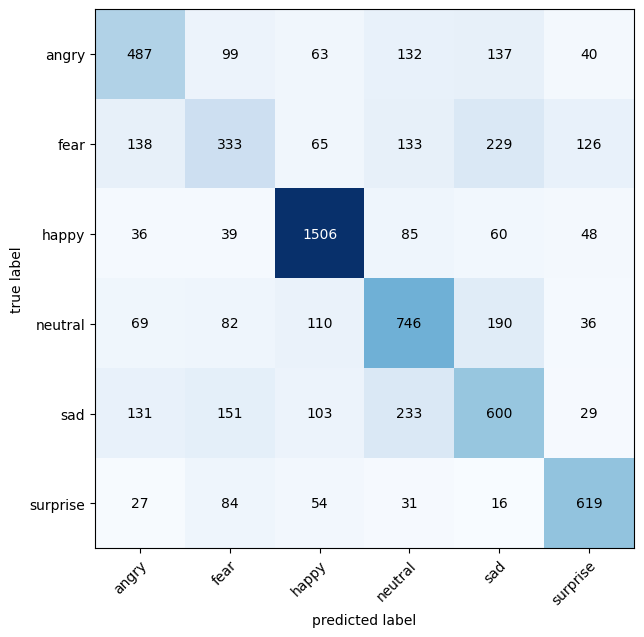

In [ ]:
confmat = ConfusionMatrix(num_classes=len(class_names_augmented_filtered), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=targets_tensor)

# Plot la confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # utilisation de numpy pour matplotlib
    class_names=class_names_augmented_filtered,
    figsize=(10, 7)
);

In [ ]:
cm = confmat_tensor.float()

# Accuracy par classe = diagonale / somme de la ligne
per_class_accuracy = cm.diag() / cm.sum(dim=1)

# Afficher
for i, class_name in enumerate(class_names_augmented_filtered):
    print(f"{class_name}: {per_class_accuracy[i]*100:.1f}%")

angry: 50.8%
fear: 32.5%
happy: 84.9%
neutral: 60.5%
sad: 48.1%
surprise: 74.5%


#3 : Saving

In [ ]:
torch.save(model.state_dict(), "fer_weights.pth")
# A mettre dans la racine d'un projet avec le fichier .py